In [1]:
import mappings as maps
import numpy as np
import time
import os 
from PIL import Image
import matplotlib.pyplot as plt
from sbox import Sbox
import ciphers
import math 


chess_path = "/Users/gaelsegura/Documents/codes/proyectos/research_repos/test_images/chess.jpg"
chess_img = Image.open(chess_path).convert('L')
chess_arr = np.array(chess_img)

baboon_path = "/Users/gaelsegura/Documents/codes/proyectos/research_repos/test_images/baboon512x512.jpg"
baboon_img = Image.open(baboon_path).convert('L')
baboon_arr = np.array(baboon_img)

# Chaos - PRNG, BLS maps  

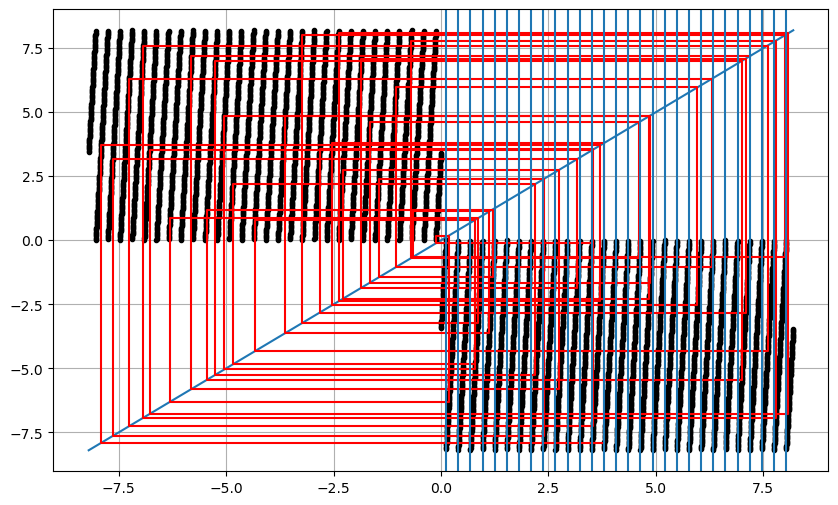

In [2]:
bls_secpar1 = [29,9.45,8.2]
bls_secpar2 = [19.4,10.5,8.2]
bls_secpar3 = [21.4,9.5,8.2]
bls_params = np.array([bls_secpar2,bls_secpar3])

x,fx,px,py = maps.mapping_blsOrbit(0.8,m=bls_secpar1[0],p=bls_secpar1[1],r=bls_secpar1[2],orbit_size=100)
xcuts = maps.bls_cutoffs(bls_secpar1[0],bls_secpar1[1],bls_secpar1[2])

fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot()
ax.grid(True, which='both')
ax.plot(x,x)
ax.plot(x,fx,'k.')
ax.plot(px,py,'r')
for i in range(len(xcuts)):
    ax.axvline(xcuts[i])

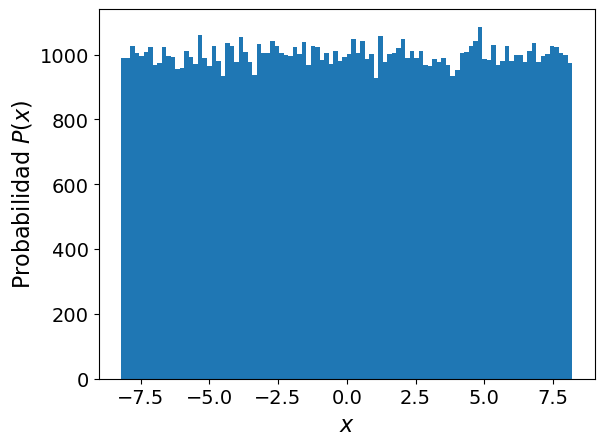

In [3]:
x_0 = 0.2
nmax = 100000
orbit = np.empty(nmax)
orbit2 = np.empty(nmax)
orbit[0] = x_0
orbit2[0] = x_0
for i in range(1,nmax):
    orbit[i] = np.abs(maps.bls_map(orbit[i-1],bls_secpar1[0],bls_secpar1[1],bls_secpar1[2]))
    orbit2[i] = maps.bls_map(orbit2[i-1],bls_secpar1[0],bls_secpar1[1],bls_secpar1[2])

plt.hist(orbit2,bins=100)
plt.xlabel('$x$',fontsize=16)
plt.ylabel("Probabilidad $P(x)$",fontsize=16)
plt.tick_params(axis='both',labelsize=14)
plt.show()

# Sbox testing with chaotic bls orbits

m_g 31.62267865490017,m_h 11.478854283976297
r 19.090089572620414
p_g 20.910746684731013,p_h27.10611920965553


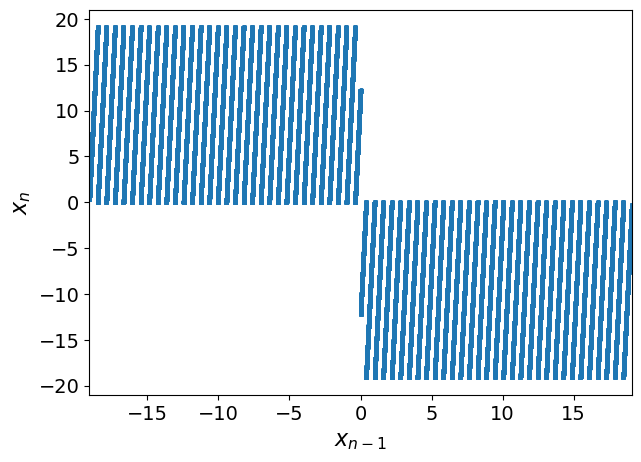

In [4]:
n,m = np.shape(baboon_arr)
m_params = np.random.uniform(4,40,2)
r_params = np.random.uniform(7,30)
p_params = np.array([np.random.uniform(r_params,30),np.random.uniform(r_params,30)])
print(f"m_g {m_params[0]},m_h {m_params[1]}")
print(f"r {r_params}")
print(f"p_g {p_params[0]},p_h{p_params[1]}")
orbit1 = []
orbit2=[]
x = np.random.uniform(-r_params,-r_params)
# y = x_0
for i in range(n*m*2):
    orbit1.append(x)
    x = maps.bls_map(x,m_params[0],p_params[0],r_params)


xn_minus1 = orbit1[:-1]
xn = orbit1[1:]
# xn_minus12 = orbit2[:-1]
# xn2 = orbit2[1:]
plt.figure(figsize=(7,5))
plt.plot(xn_minus1, xn, '.', markersize=5, label="Orbit points")
# plt.plot(xn_minus12, xn2, '.', markersize=5, label="Orbit points")
plt.xlabel('$x_{n-1}$',fontsize=16)
plt.xlim(min(orbit1),max(orbit1))
plt.ylabel("$x_n$",fontsize=16)
plt.tick_params(axis='both',labelsize=14)

# plt.grid()

plt.show()
    

# Delayed sequence: $\gamma_i = (((x_i+x_{i-l_1}+x_{i-l_2})*10^8)\mod 255)+1  $

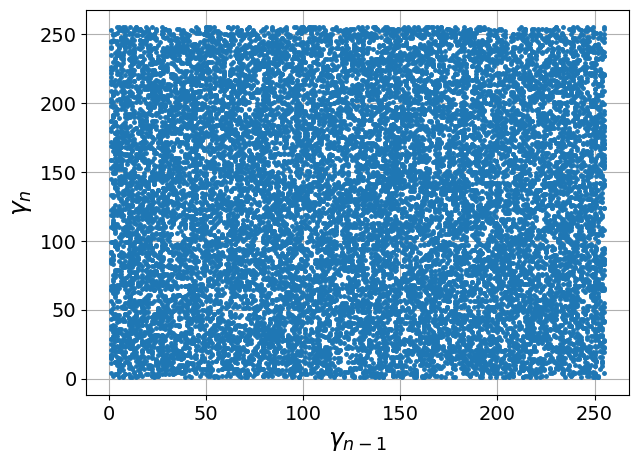

In [5]:
def orbit_delaytseries(x01,delay,mparams,pparams,rparams):
    x1 = [x01]
    m1 = []
    m2 = []
    m1_seq = 0
    m2_seq = 0
    delayhf = delay/2
   
    for i in range(18000):
        x1.append(maps.bls_map(x1[i],mparams[0],pparams[0],rparams)) #x1n+1=f(x1n)
        # x2.append(pwlm(x2[i],f2[0],f2[1],f2[2]))

        if i>= delay:
            m1_seq = (((x1[int(i-(delay))]+x1[int(i-(delayhf))]+x1[int(i)])*(10**8))%255 + 1)
            # m2_seq = (x2[int(i-(delay))]+x2[int(i-(delayhf+1))]+x2[int(i)])%256
            m1.append(np.floor(m1_seq))
            # m2.append(m2_seq)

    return m1


orbital = orbit_delaytseries(orbit1[0],delay=10,mparams=m_params,pparams=p_params,rparams=r_params)

mn_minus1 = orbital[:-1]
mn = orbital[1:]
# mn_minus12 = orbital[1][:-1]
# mn2 = orbital[1][1:]
plt.figure(figsize=(7, 5))
plt.plot(mn_minus1, mn, '.', markersize=5, label="Orbit points")
#plt.plot(xn_minus12, xn2, '.', markersize=5, label="Orbit points")

plt.xlabel('$\gamma_{n-1}$',fontsize=18)

plt.ylabel("$\gamma_{n}$",fontsize=18)

plt.tick_params(axis='both',labelsize=14)

plt.grid()
plt.show()

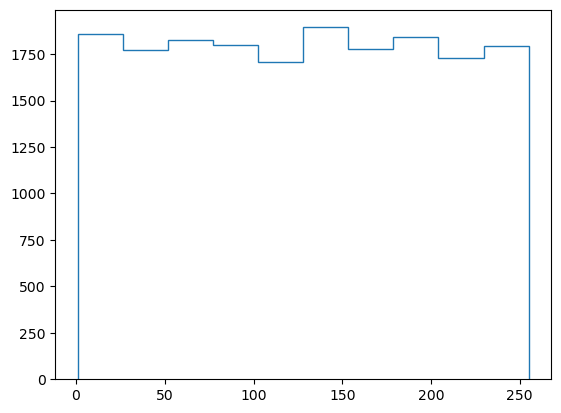

In [6]:
counts, bins = np.histogram(orbital)
plt.stairs(counts, bins)

# Generated SBox, random conditions m,p,r for BLS.  

In [7]:
def blsDelay_sbox(x01,mparams,pparams,rparams,delay=10,sblen=2**8):
    startT = time.time()
    x1 = [x01]
    m_seq = 0
    delayhf = int(delay*0.5)
    sb = []
    zet = []
    i = 0

    while len(sb) < sblen:
        x1.append(maps.bls_map(x1[i],m=mparams,p=pparams,r=rparams)) #x1(n+1)=f(x1(n))
        

        if i>= 1000:
            m1_seq = ((x1[int(i-(delay))]+x1[int(i-(delayhf))]+x1[int(i)])*(10**8)%sblen)
            # m2_seq = (x2[int(i-(delay))]+x2[int(i-(delayhf+1))]+x2[int(i)])%256
            Zi = int(np.floor(m1_seq))
            zet.append(Zi)
            if Zi not in sb: sb.append(Zi)

        i+=1
    
    endT = time.time()
    # print("Time:")
    # print(endT - startT)
    # print("End, rotcont:")
    return sb,zet

sbtest,zet = blsDelay_sbox(2,m_params[0],p_params[0],r_params)

sbox = Sbox(sbtest)
print(len(sbox.table))
print(sbox.bic_average(sbox.bicsac_analysis()))
print(sbox.bic_average(sbox.bicnonl_analysis()))
print(np.average(sbox.sac_analysis()))
print(np.average(sbox.nonlinearity_analysis()))
print(sbox.differential_probability())
print(sbox.linear_probability())




256
(0.5050920758928571, [0.5234375, 0.501953125, 0.505859375, 0.498046875, 0.513671875, 0.517578125, 0.517578125, 0.490234375, 0.490234375, 0.513671875, 0.494140625, 0.5234375, 0.50390625, 0.501953125, 0.51953125, 0.49609375, 0.50390625, 0.52734375, 0.51171875, 0.50390625, 0.4765625, 0.515625, 0.4921875, 0.490234375, 0.494140625, 0.5078125, 0.509765625, 0.498046875])
(102.85714285714286, [106, 104, 106, 102, 100, 104, 94, 106, 100, 104, 104, 102, 100, 102, 98, 100, 100, 102, 108, 104, 104, 108, 102, 108, 108, 100, 102, 102])
0.5014703125000001
104.0
0.0390625
0.070556640625


In [11]:
zet[0:3]

[236, 0, 66]

# 3 sboxes from the bls chaotic sequences

In [ ]:
def chaos_enigmarot(image):
    k=3

    n,m = np.shape(baboon_arr)
    m_params = np.random.uniform(4,40,k)
    r_params = np.random.uniform(7,30)
    p_params = np.array(np.random.uniform(r_params,30,3))
    print(f"m_g {m_params[0]},m_h {m_params[1]}")
    print(f"r {r_params}")
    print(f"p_g {p_params[0]},p_h{p_params[1]}")
    x = np.random.uniform(-r_params,-r_params)
    
   
    
    cipher_arr = np.zeros((n,m))
    binarr = bls_binaryOrbit(2,orbsize=n*m*2)[0]
    rotcont = 0
    randbinpairs = [int(f"{binarr[i]}{binarr[i+1]}",2) for i in range(len(binarr)-1)]

    for c in range(n):
        for r in range(m):
            aux = sboxes[0].table[int(img_array[c,r])]
            auximg1[c,r] = aux
            aux = sboxes[1].table[int(aux)]
            auximg2[c,r] = aux
            aux = sboxes[2].table[int(aux)]
            cipher_arr[c,r] = aux
            # print(np.mod(randbinpairs[rotcont],3))
            sboxes[np.mod(randbinpairs[rotcont],3)].rotation()
            # print(sboxes[np.mod(randbinpairs[rotcont],3)].rot_cont)
            rotcont = (sboxes[0].rot_cont+sboxes[1].rot_cont+sboxes[2].rot_cont)
            # print(rotcont,n*m)



    endT = time.time()
    # print("Time:")
    # print(endT - startT)
    # print("End, rotcont:")
    # print(sboxes[0].rot_cont,sboxes[1].rot_cont,sboxes[2].rot_cont)
    # sboxes[0].reset_table()
    # sboxes[1].reset_table()
    # sboxes[2].reset_table()
    # print(sboxes[0].table)
    # print(sboxes[1].table)
    # print(sboxes[2].table)
    # rot_cont = [sboxes[0].rot_cont,sboxes[1].rot_cont,sboxes[2].rot_cont]
    
    return cipher_arr,auximg1,auximg2,xinits,sboxes



# BLS Composed mapping
## [19.4,10.5,8.2], [21.4,9.5,8.2]

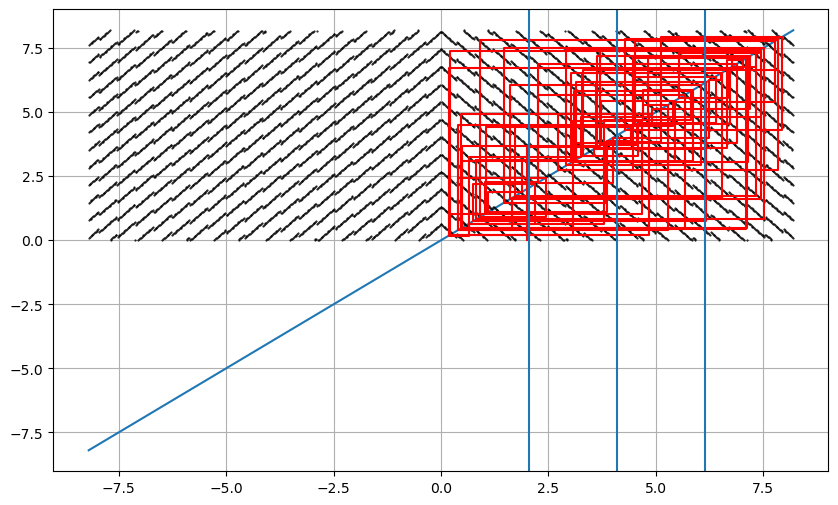

In [4]:
y,fy,px,py = maps.mapping_blsCompOrbit(2,paramsSet=bls_params,orbit_size=200)
deltax = bls_params[0,2]/4
xsep = [deltax*i for i in range(1,4)]

fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot()
ax.grid(True, which='both')

ax.plot(x,x)
ax.plot(y,fy,'k.',markersize=1)
ax.plot(px,py,'r')
for i in range(len(xsep)):    
    ax.axvline(xsep[i])


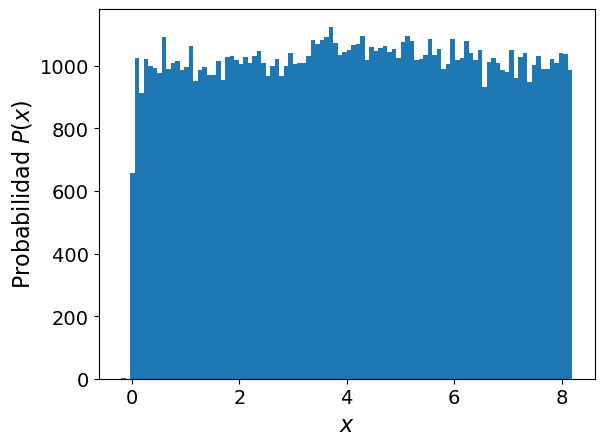

In [5]:
x_0 = -0.2
nmax = 100000
orbit = np.empty(nmax)
orbit2 = np.empty(nmax)
orbit[0] = x_0
orbit2[0] = x_0
for i in range(1,nmax):
    orbit[i] = np.abs(maps.bls_composed(orbit[i-1],paramsSet=bls_params))
    orbit2[i] = maps.bls_composed(orbit2[i-1],paramsSet=bls_params)

plt.hist(orbit2,bins=100)
plt.xlabel('$x$',fontsize=16)
plt.ylabel("Probabilidad $P(x)$",fontsize=16)
plt.tick_params(axis='both',labelsize=14)
plt.show()

# Chaotic sequence for SB rotation test, old boxes with bls sequence

In [ ]:

def bls_binaryOrbit(x0,params=np.array([[19.4,10.5,8.2],[21.4,9.5,8.2]]),orbsize=10000):
    bls_xseps = maps.bls_cutoffs(params[0,0],params[0,1],params[0,2])
    xorb = [x0]
    xbin = [maps.binary_split(xorb[0],bls_xseps)]
    for i in range(orbsize):
        xorb.append(maps.bls_map(xorb[i],params[0,0],params[0,1],params[0,2]))
        xbin.append(maps.binary_split(abs(xorb[i]),bls_xseps))
        # print(xorb[i],xbin[i])
    
    return xbin,xorb

ediesca = [243, 130, 238, 170, 157, 85, 151, 139, 164, 253, 89, 201, 70, 42, 230, 28, 74, 0, 31, 120, 101, 79, 141, 106, 125, 119, 241, 1, 121, 91, 161, 100, 199, 51, 150, 191, 72, 207, 214, 21, 218, 49, 183, 80, 179, 165, 9, 195, 209, 34, 138, 192, 99, 6, 115, 65, 152, 174, 7, 124, 20, 197, 155, 17, 109, 67, 208, 163, 2, 69, 145, 252, 44, 75, 12, 60, 237, 185, 22, 36, 216, 37, 104, 168, 59, 187, 128, 166, 233, 215, 118, 111, 206, 84, 213, 134, 149, 171, 73, 248, 32, 50, 33, 148, 159, 131, 143, 103, 43, 71, 61, 198, 133, 88, 40, 56, 114, 245, 136, 200, 190, 202, 181, 107, 29, 94, 87, 110, 11, 26, 244, 255, 246, 247, 14, 108, 186, 62, 235, 222, 182, 232, 140, 63, 98, 193, 3, 126, 221, 240, 97, 24, 212, 113, 66, 58, 234, 254, 158, 83, 102, 19, 135, 95, 156, 23, 250, 123, 41, 162, 219, 178, 4, 47, 127, 76, 45, 55, 203, 204, 236, 54, 251, 82, 176, 223, 142, 30, 177, 144, 184, 217, 160, 78, 153, 231, 129, 38, 146, 132, 194, 116, 64, 147, 16, 13, 92, 188, 8, 96, 227, 18, 220, 189, 172, 52, 173, 167, 229, 210, 35, 154, 5, 68, 122, 175, 53, 249, 169, 48, 196, 205, 57, 117, 112, 10, 180, 25, 226, 211, 224, 81, 39, 242, 93, 27, 105, 90, 77, 86, 225, 137, 228, 15, 239, 46]
nl96 = [110, 104, 108, 126, 204, 2, 20, 109, 48, 90, 114, 8, 252, 226, 107, 163, 102, 31, 158, 105, 225, 141, 16, 85, 232, 161, 175, 177, 115, 88, 134, 146, 92, 98, 47, 148, 55, 210, 130, 81, 224, 99, 40, 165, 162, 164, 229, 3, 160, 37, 50, 97, 168, 41, 183, 205, 113, 221, 192, 59, 184, 136, 86, 111, 151, 242, 32, 194, 65, 208, 9, 91, 182, 231, 198, 189, 72, 203, 106, 131, 238, 73, 153, 135, 38, 222, 6, 101, 60, 173, 46, 223, 191, 100, 196, 176, 11, 245, 71, 66, 70, 93, 10, 76, 230, 89, 42, 123, 64, 235, 207, 22, 211, 29, 213, 140, 249, 216, 74, 178, 219, 174, 171, 243, 35, 33, 127, 25, 57, 133, 142, 124, 24, 179, 26, 112, 45, 78, 152, 181, 17, 172, 30, 247, 149, 132, 39, 138, 67, 1, 215, 241, 69, 228, 96, 143, 13, 166, 188, 118, 201, 121, 80, 44, 234, 56, 167, 52, 125, 197, 254, 62, 255, 169, 84, 5, 49, 150, 0, 157, 144, 129, 227, 15, 61, 187, 155, 147, 128, 156, 63, 18, 82, 77, 185, 75, 122, 12, 244, 209, 233, 4, 170, 87, 103, 220, 180, 53, 117, 21, 23, 186, 95, 83, 139, 28, 19, 34, 212, 193, 159, 116, 7, 253, 236, 137, 79, 239, 190, 94, 250, 202, 217, 214, 154, 68, 251, 206, 246, 54, 200, 199, 51, 145, 27, 195, 240, 237, 218, 248, 58, 36, 43, 14, 120, 119]
aes_sbox = [99, 124, 119, 123, 242, 107, 111, 197, 48, 1, 103, 43, 254, 215, 171, 118, 202, 130, 201, 125, 250, 89, 71, 240, 173, 212, 162, 175, 156, 164, 114, 192, 183, 253, 147, 38, 54, 63, 247, 204, 52, 165, 229, 241, 113, 216, 49, 21, 4, 199, 35, 195, 24, 150, 5, 154, 7, 18, 128, 226, 235, 39, 178, 117, 9, 131, 44, 26, 27, 110, 90, 160, 82, 59, 214, 179, 41, 227, 47, 132, 83, 209, 0, 237, 32, 252, 177, 91, 106, 203, 190, 57, 74, 76, 88, 207, 208, 239, 170, 251, 67, 77, 51, 133, 69, 249, 2, 127, 80, 60, 159, 168, 81, 163, 64, 143, 146, 157, 56, 245, 188, 182, 218, 33, 16, 255, 243, 210, 205, 12, 19, 236, 95, 151, 68, 23, 196, 167, 126, 61, 100, 93, 25, 115, 96, 129, 79, 220, 34, 42, 144, 136, 70, 238, 184, 20, 222, 94, 11, 219, 224, 50, 58, 10, 73, 6, 36, 92, 194, 211, 172, 98, 145, 149, 228, 121, 231, 200, 55, 109, 141, 213, 78, 169, 108, 86, 244, 234, 101, 122, 174, 8, 186, 120, 37, 46, 28, 166, 180, 198, 232, 221, 116, 31, 75, 189, 139, 138, 112, 62, 181, 102, 72, 3, 246, 14, 97, 53, 87, 185, 134, 193, 29, 158, 225, 248, 152, 17, 105, 217, 142, 148, 155, 30, 135, 233, 206, 85, 40, 223, 140, 161, 137, 13, 191, 230, 66, 104, 65, 153, 45, 15, 176, 84, 187, 22]

k=3
m1_params = np.random.uniform(0.7,1,2)
m2_params = np.random.uniform(2,10,2)
b1_params = np.random.uniform(8,45,2)
randparams = [[m1_params[0],m2_params[0],b1_params[0]],[m1_params[1],m2_params[1],b1_params[1]]]
b2_invariant = b1_params*(m2_params/m1_params)
xinits = [[np.random.uniform(-np.floor(b2_invariant[0]),np.floor(b2_invariant[0])),np.random.uniform(-np.floor(b2_invariant[1]),np.floor(b2_invariant[1]))] for i in range(k)]
# sboxes = [Sbox(ciphers.generate_sbox(xinits[i][0],xinits[i][1],f1=params[0],f2=params[1])) for i in range(k)]

def generate_sbox(x01,x02,delay=10,f1=[0.8,5,40.8],f2=[0.9,4,31],sblen=256):
    startT = time.time()
    x1 = [x01]
    x2 = [x02]
    m1_seq = 0
    m2_seq = 0
    delayhf = int(delay*0.5)
    sb = []
    zet = []
    i = 0

    while len(sb) < sblen:
        x1.append(maps.pwlm(x1[i],f1[0],f1[1],f1[2])) #x1(n+1)=f(x1(n))
        x2.append(maps.pwlm(x2[i],f2[0],f2[1],f2[2]))

        if i>= 1000:
            m1_seq = (x1[int(i-(delay))]+x1[int(i-(delayhf))]+x1[int(i)])%256
            m2_seq = (x2[int(i-(delay))]+x2[int(i-(delayhf+1))]+x2[int(i)])%256
            Zi = math.floor((m1_seq+m2_seq)%256)
            zet.append(Zi)
            if Zi not in sb: sb.append(Zi)

        i+=1
    
    endT = time.time()
    # print("Time:")
    # print(endT - startT)
    # print("End, rotcont:")
    return sb#,zet

def chaos_enigmarot(image):
    k=3
    m1_params = np.random.uniform(0.7,1,2)
    m2_params = np.random.uniform(2,10,2)
    b1_params = np.random.uniform(8,45,2)
    params = [[m1_params[0],m2_params[0],b1_params[0]],[m1_params[1],m2_params[1],b1_params[1]]]
    b2_invariant = b1_params*(m2_params/m1_params)
    xinits = [[np.random.uniform(-np.floor(b2_invariant[0]),np.floor(b2_invariant[0])),np.random.uniform(-np.floor(b2_invariant[1]),np.floor(b2_invariant[1]))] for i in range(k)]
    img_array = np.array(image)
    auximg1, auximg2 = np.array(image), np.array(image)
    n,m = img_array.shape[0],img_array.shape[1]
    startT = time.time()
    sboxes = [Sbox(generate_sbox(xinits[i][0],xinits[i][1],f1=params[0],f2=params[1])) for i in range(k)]
    # print(sboxes[0].table)
    # print(sboxes[1].table)
    # print(sboxes[2].table)
    
    cipher_arr = np.zeros((n,m))
    binarr = bls_binaryOrbit(2,orbsize=n*m*2)[0]
    rotcont = 0
    randbinpairs = [int(f"{binarr[i]}{binarr[i+1]}",2) for i in range(len(binarr)-1)]

    for c in range(n):
        for r in range(m):
            aux = sboxes[0].table[int(img_array[c,r])]
            auximg1[c,r] = aux
            aux = sboxes[1].table[int(aux)]
            auximg2[c,r] = aux
            aux = sboxes[2].table[int(aux)]
            cipher_arr[c,r] = aux
            # print(np.mod(randbinpairs[rotcont],3))
            sboxes[np.mod(randbinpairs[rotcont],3)].rotation()
            # print(sboxes[np.mod(randbinpairs[rotcont],3)].rot_cont)
            rotcont = (sboxes[0].rot_cont+sboxes[1].rot_cont+sboxes[2].rot_cont)
            # print(rotcont,n*m)



    endT = time.time()
    # print("Time:")
    # print(endT - startT)
    # print("End, rotcont:")
    # print(sboxes[0].rot_cont,sboxes[1].rot_cont,sboxes[2].rot_cont)
    # sboxes[0].reset_table()
    # sboxes[1].reset_table()
    # sboxes[2].reset_table()
    # print(sboxes[0].table)
    # print(sboxes[1].table)
    # print(sboxes[2].table)
    # rot_cont = [sboxes[0].rot_cont,sboxes[1].rot_cont,sboxes[2].rot_cont]
    
    return cipher_arr,auximg1,auximg2,xinits,sboxes



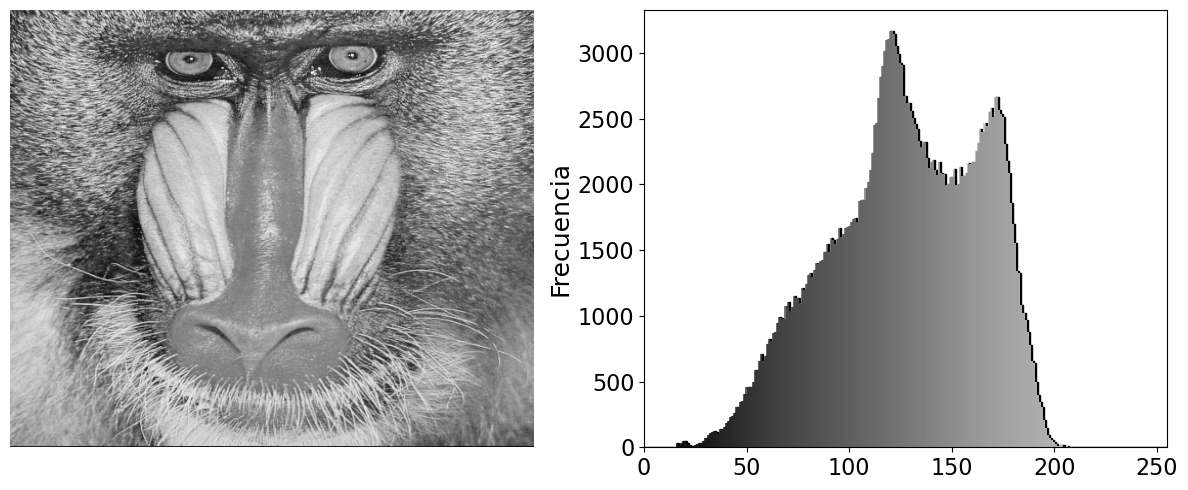

In [13]:
# cipher_arr,auximg1,auximg2,xinits,sboxes = chaos_enigmarot(baboon_img)#,xinits=xinits,params=randparams)
hist1,hist2 = ciphers.plot_image_and_histogram(baboon_arr)

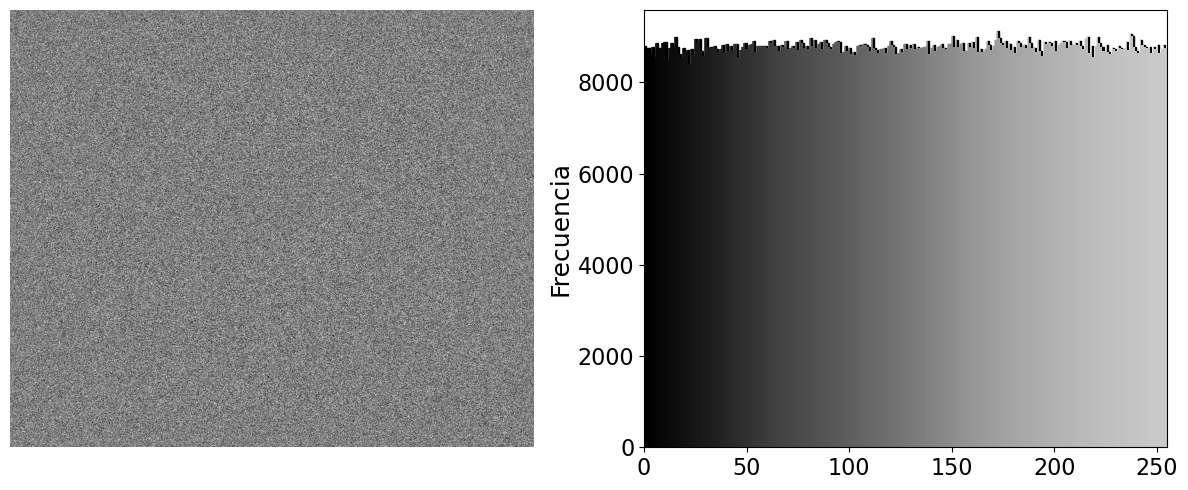

In [15]:
cipher_arr,auximg1,auximg2,xinits,sboxes = chaos_enigmarot(chess_arr)#,xinits=xinits,params=randparams)
hist1,hist2 = ciphers.plot_image_and_histogram(cipher_arr)

# ZigZag image permutation development phases

In [71]:
from typing import Union, List

def extended_zigzag_transform(image: np.ndarray, bit_sequence: Union[str, List[int]]) -> np.ndarray:
    """
    Apply extended Zigzag transform to a 2D image.

    Parameters
    ----------
    image : np.ndarray
        2D array (M x N) to be permuted.
    bit_sequence : str or list of int
        Pseudorandom bits (0/1) of length exactly:
        2 + sum_{k=2}^{n-1} bits_for_diagonal(k)
        where n = M+N-1 and bits_for_diagonal(k) depends on diagonal length.

    Returns
    -------
    np.ndarray
        Permuted 2D array of same shape as image.
    """
    # Ensure bit_sequence is a list of ints
    if isinstance(bit_sequence, str):
        bits = [int(b) for b in bit_sequence]
    else:
        bits = list(bit_sequence)

    M, N = image.shape
    n = M + N - 1

    # Helper: get indices of main diagonal k (1‑based) in ascending column order
    def get_main_diag(k):
        # condition: j - i = k - M
        start_i = max(1, 1 + (k - M))
        end_i = min(M, N + (k - M))
        if start_i > end_i:
            return []
        # iterate i increasing → j increasing
        indices = []
        for i in range(start_i, end_i + 1):
            j = i + (k - M)
            indices.append((i-1, j-1))   # 0‑based
        return indices

    # Helper: get indices of anti‑diagonal k (1‑based) in ascending column order
    def get_anti_diag(k):
        # condition: i + j = k + 1
        start_i = max(1, k + 1 - N)
        end_i = min(M, k)
        if start_i > end_i:
            return []
        # iterate i decreasing → j increasing
        indices = []
        for i in range(end_i, start_i - 1, -1):
            j = k + 1 - i
            indices.append((i-1, j-1))
        return indices

    # Precompute all diagonals (both types) for indices 1..n
    main_diags = [get_main_diag(k) for k in range(1, n+1)]
    anti_diags = [get_anti_diag(k) for k in range(1, n+1)]

    # --- Read zigzag mode (first 2 bits) ---
    if len(bits) < 2:
        raise ValueError("Bit sequence too short for zigzag mode")
    mode = (bits[0] << 1) | bits[1]
    bit_ptr = 2

    # --- Read per‑diagonal parameters ---
    diag_params = {}  # key: diagonal index k (1..n), value: (x,y,z)
    for k in range(2, n):  # k = 2 ... n-1
        L = len(main_diags[k-1])   # length of diagonal k
        if L == 2:
            # 1 bit: x
            if bit_ptr + 1 > len(bits):
                raise ValueError("Bit sequence too short for diagonal parameters")
            x = bits[bit_ptr]
            bit_ptr += 1
            y = 0
            z = 0
        elif L == 3:
            # 2 bits: x, y
            if bit_ptr + 2 > len(bits):
                raise ValueError("Bit sequence too short for diagonal parameters")
            x = bits[bit_ptr]
            y = bits[bit_ptr+1]
            bit_ptr += 2
            z = 0
        else:  # L >= 4
            # 3 bits: x, y, z
            if bit_ptr + 3 > len(bits):
                raise ValueError("Bit sequence too short for diagonal parameters")
            x = bits[bit_ptr]
            y = bits[bit_ptr+1]
            z = bits[bit_ptr+2]
            bit_ptr += 3
        diag_params[k] = (x, y, z)

    # --- Build traversal order ---
    if mode == 0:          # anti‑diagonals increasing
        diag_set = anti_diags
        diag_indices = range(1, n+1)
    elif mode == 1:        # main diagonals increasing
        diag_set = main_diags
        diag_indices = range(1, n+1)
    elif mode == 2:        # anti‑diagonals decreasing
        diag_set = anti_diags
        diag_indices = range(n, 0, -1)
    else:                  # mode == 3, main diagonals decreasing
        diag_set = main_diags
        diag_indices = range(n, 0, -1)

    traversal = []
    for k in diag_indices:
        indices = diag_set[k-1]   # 0‑based list of (r,c)
        L = len(indices)
        if k == 1 or k == n:
            # first/last diagonal: no reordering
            traversal.append(indices)
        else:
            x, y, z = diag_params[k]
            # split into halves
            mid = (L + 1) // 2   # ceil(L/2)
            P1 = indices[:mid]
            P2 = indices[mid:]
            if y:
                P1 = P1[::-1]
            if z:
                P2 = P2[::-1]
            if x:
                seq = P2 + P1
            else:
                seq = P1 + P2
            traversal.append(seq)

    # --- Apply permutation ---
    # Flatten original image row‑major
    flat_original = image.flatten()
    new_flat = np.array([flat_original[r*N + c] for (r, c) in traversal], dtype=image.dtype)
    
    return new_flat.reshape(M, N)



# Create a simple 3x4 image
img = baboon_arr
print("Original image:\n", img)

# Required number of bits:
# M=3, N=4 → n=6
# bits: mode (2) + diagonals 2..5 (bits based on length)
# Diagonal lengths: 1,2,3,4,3,2,1? Wait n=6 means diagonals 1..6.
# Actual lengths for 3x4: k=1:1, k=2:2, k=3:3, k=4:3, k=5:2, k=6:1.
# So we need bits for k=2 (2 bits: length2 → 1 bit), k=3 (3:2 bits), k=4 (3:2 bits), k=5 (2:1 bit)
# Total bits = 2 + 1+2+2+1 = 8 bits.
# bit_seq = [0, 1,  # mode=1 (main diag increasing)
#             0,     # k=2 (x=0)
#             1,0,   # k=3 (x=1,y=0)
#             0,1,   # k=4 (x=0,y=1)
#             1]     # k=5 (x=1)
bit_seq = maps.bls_binaryOrbit(3.1,orbsize=3*(n*m-1)-10)[0]
transformed = extended_zigzag_transform(img, bit_seq)
print("Transformed image:\n", transformed)

Original image:
 [[141  64  58 ... 113 148 168]
 [116 103  50 ... 128 144 124]
 [ 82 114  56 ... 102  92  86]
 ...
 [137 141 137 ...  87  93  83]
 [150 137 129 ...  84  85  75]
 [ 25  26  29 ...  22  19  20]]


ValueError: not enough values to unpack (expected 2, got 1)

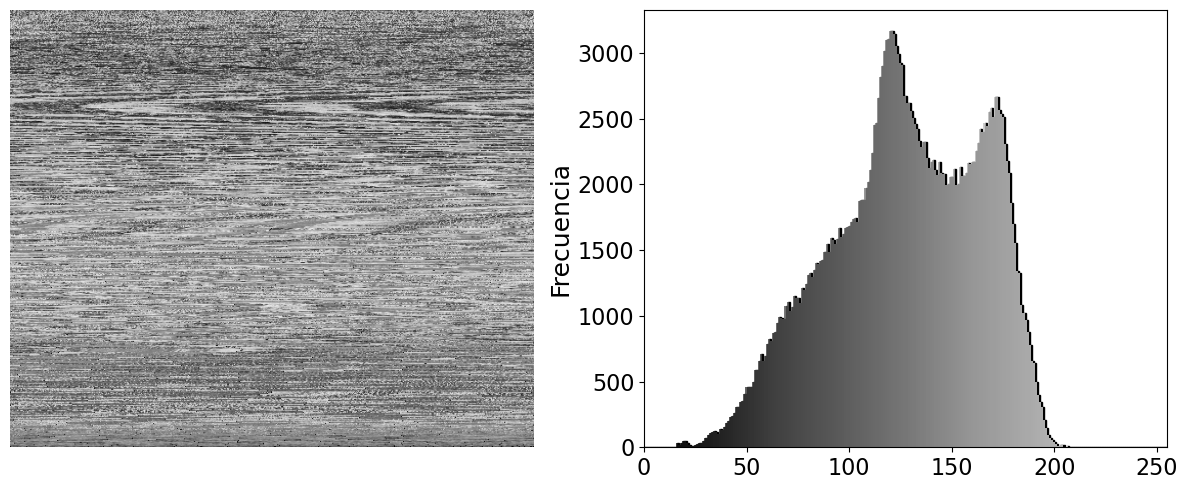

(array([  0.,   1.,   2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.,  10.,
         11.,  12.,  13.,  14.,  15.,  16.,  17.,  18.,  19.,  20.,  21.,
         22.,  23.,  24.,  25.,  26.,  27.,  28.,  29.,  30.,  31.,  32.,
         33.,  34.,  35.,  36.,  37.,  38.,  39.,  40.,  41.,  42.,  43.,
         44.,  45.,  46.,  47.,  48.,  49.,  50.,  51.,  52.,  53.,  54.,
         55.,  56.,  57.,  58.,  59.,  60.,  61.,  62.,  63.,  64.,  65.,
         66.,  67.,  68.,  69.,  70.,  71.,  72.,  73.,  74.,  75.,  76.,
         77.,  78.,  79.,  80.,  81.,  82.,  83.,  84.,  85.,  86.,  87.,
         88.,  89.,  90.,  91.,  92.,  93.,  94.,  95.,  96.,  97.,  98.,
         99., 100., 101., 102., 103., 104., 105., 106., 107., 108., 109.,
        110., 111., 112., 113., 114., 115., 116., 117., 118., 119., 120.,
        121., 122., 123., 124., 125., 126., 127., 128., 129., 130., 131.,
        132., 133., 134., 135., 136., 137., 138., 139., 140., 141., 142.,
        143., 144., 145., 146., 147., 

In [63]:
# bab_perm = np.matrix(np.split(transformed,np.shape(baboon_arr)[1]))
ciphers.plot_image_and_histogram(transformed)

In [54]:
bit_seq

[0,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 1,
 1,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 1,
 0,
 0,
 1,
 1,
 1,
 0,
 1,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 1,
 1,
 1,
 0,
 1,
 0,
 1,
 1,
 1,
 1,
 0,
 1,
 1,
 0,
 1,
 0,
 1,
 1,
 0,
 1,
 0,
 1,
 1,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 0,
 1,
 1,
 0,
 0,
 1,
 0,
 1,
 1,
 0,
 0,
 1,
 1,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 1,
 1,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 0,
 1,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 1,
 0,
 1,
 1,
 0,
 1,
 1,
 0,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 0,
 0,
 0,
 1,
 0,
 1,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 1,
 1,
 1,
 0,
 0,
 0,


In [52]:
print(len(transformed))

262144
